# Temperature Prediction

## Objective
Predict the **temperature** based on humidity data.


## Dataset Overview
The dataset contains hourly or daily readings of humidity and temperature.


## Workflow
1. Load the dataset  
2. Explore and clean the data  
3. Train a regression model  
4. Evaluate predictions


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
# Load the dataset
df = pd.read_csv("humidity.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701548 entries, 0 to 701547
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   sensor_id    701548 non-null  int64  
 1   lat          701548 non-null  float64
 2   lon          701548 non-null  float64
 3   pressure     701548 non-null  float64
 4   temperature  701548 non-null  float64
 5   humidity     701548 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 32.1 MB


,sensor_id,lat,lon,pressure,temperature,humidity
0,2266,42.738,23.272,95270.27,23.46,62.48
1,2292,42.663,23.273,94355.83,23.06,59.46
2,3096,42.700,23.360,95155.81,26.53,44.38
3,3428,42.624,23.406,94679.57,28.34,38.28
4,3472,42.669,23.318,94327.88,26.31,46.37


## Exploratory Data Analysis


In [8]:

# Check for missing values
df.isnull().sum()


# Display summary statistics
df.describe()



,sensor_id,lat,lon,pressure,temperature,humidity
count,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000,701548.000000
mean,2835.419842,42.679722,23.333739,94965.292500,24.754990,48.348949
std,798.018890,0.025568,0.039365,2577.210945,14.013001,20.907247
min,1764.000000,42.622000,23.240000,0.000000,-145.120000,0.000000
25%,2224.000000,42.665000,23.310000,94528.017500,20.630000,34.140000
50%,2323.000000,42.685000,23.332000,95005.480000,24.780000,48.350000
75%,3474.000000,42.694000,23.360000,95405.132500,29.870000,62.940000
max,4661.000000,42.738000,23.419000,164926.750000,61.170000,100.000000


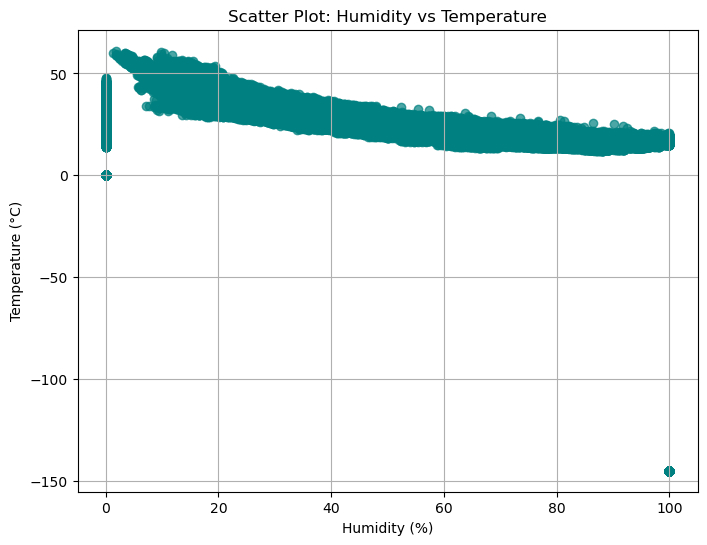

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(df['humidity'], df['temperature'], color='teal', alpha=0.7)

# Add labels and title
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.title('Scatter Plot: Humidity vs Temperature')
plt.grid(True)

# Show the plot
plt.show()
# Scatter plot to observe relationship

## Data Preprocessing

In [14]:
# 📥 Drop any rows with missing values
df.dropna(inplace=True)

# 🎯 Define features (X) and target (y)
# We'll predict temperature based on humidity
X = df[['humidity']]  # Feature must be a 2D DataFrame
y = df['temperature'] # Target is 1D (Series)

# ✂️ Split into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (561238, 1)
Test set size: (140310, 1)


## Model Training

In [16]:
# 🏋️‍♀️ Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 🔮 Predict on the test set
y_pred = model.predict(X_test)

# ✅ Print first few predicted vs actual values
print('Predicted:', y_pred[:5])
print('Actual:', y_test.values[:5])

Predicted: [14.93681105 32.06608596 18.21935337 23.49462409 28.31265918]
Actual: [16.58 31.45 20.69 23.22 32.99]


## Evaluation


In [23]:

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 144.08
R² Score: 0.26


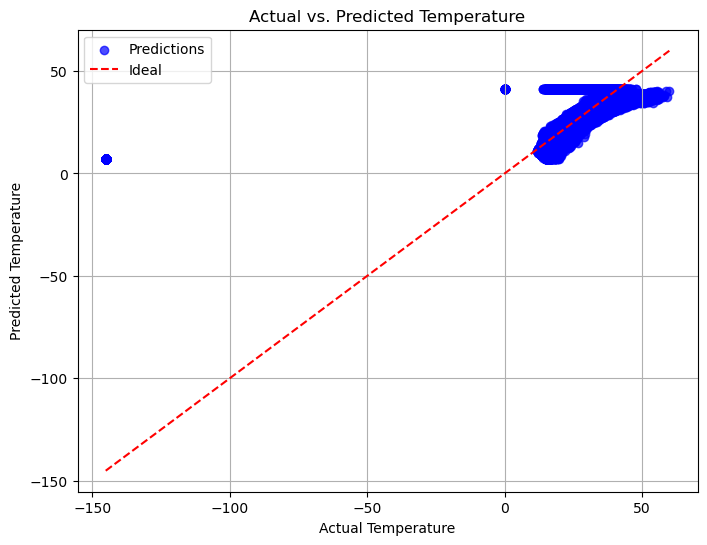

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', label='Ideal')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs. Predicted Temperature')
plt.legend()
plt.grid(True)
plt.show()


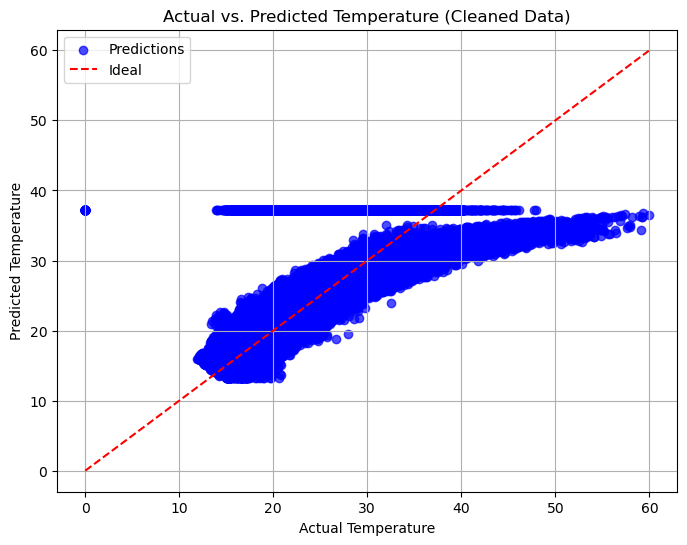

Mean Squared Error: 17.37
R² Score: 0.58


In [31]:
# 🔍 1) Filter the data to remove extreme temperatures
df = df[df['temperature'] > -50]

# 🎯 2) Redefine features & target
X = df[['humidity']]
y = df['temperature']

# ✂️ 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🤖 4) Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# 🔮 5) Predict
y_pred = model.predict(X_test)

# 📊 6) Plot Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', label='Ideal')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs. Predicted Temperature (Cleaned Data)')
plt.legend()
plt.grid(True)
plt.show()

# ✅ 7) Print new metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


In [29]:
## 🏁 Conclusion
✅ We built a simple linear regression model to predict temperature from humidity.  
✅ After cleaning extreme values, the model achieved:
- Mean Squared Error: 17.37  
- R² Score: 0.58  

💡 Consider using more features (e.g. pressure, wind speed), polynomial regression, or time-series models to further improve accuracy.


SyntaxError: invalid character '✅' (U+2705) (353051847.py, line 2)